In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)


In [3]:
def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

In [4]:
fn = f"../results/OnlinePAFM/PVAFM_GBT_onlineoffline_gamma0.9_oh_w_time200_600_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_arr = data["pregrets_online"]
PREGRETS_random_arr = data["pregrets_offline"]
print(PREGRETS_arr)

[[0.26996331 0.02450598 0.         ... 0.00982435 0.00970222 0.00958946]
 [0.77851861 0.76947402 0.82641943 ... 0.         0.         0.        ]
 [1.09342528 1.10993587 1.09159596 ... 0.01225851 0.01188842 0.01150015]
 ...
 [0.80226315 0.81083367 0.82628898 ... 0.00542893 0.00533707 0.0052579 ]
 [0.91176296 0.92530537 0.88971203 ... 0.00982435 0.00970222 0.00958946]
 [0.47590737 0.47173301 0.55803146 ... 0.         0.         0.        ]]


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_34052/1671028746.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


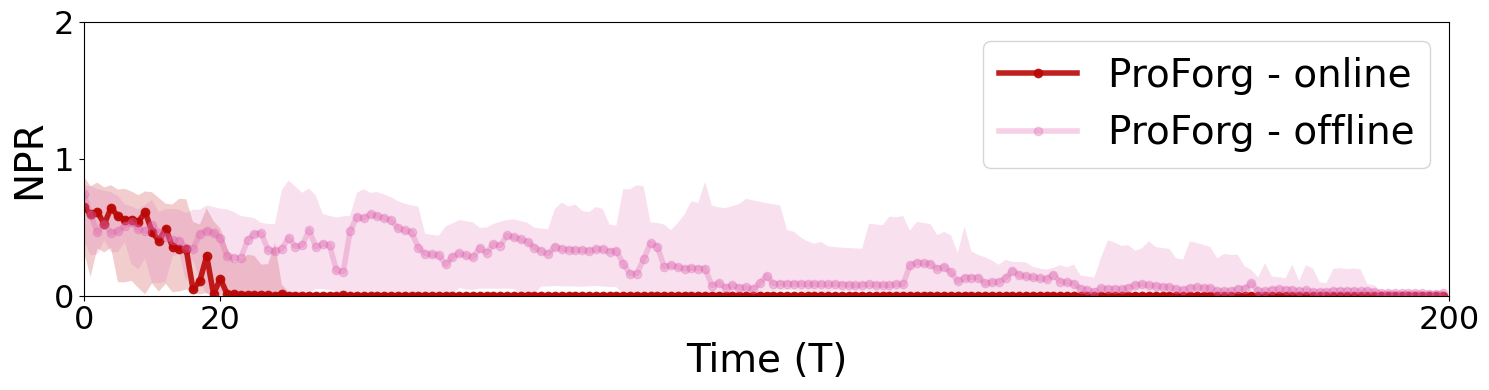

In [5]:
plt.figure(figsize=(15, 4))

linewidth = 4
fontsize = 28
pvafm_df_offline,_ = get_close_colors("PuRd", start = 0.5, delta = 0.65 , n = 2) 
_, pvafm_df_online = get_close_colors("OrRd", start = 0.2, delta = 0.65 , n = 2) 
pafm_nn, pafm_nn_opt = get_close_colors("GnBu", start=0.8, delta=0.25,n = 2)
rl_fqi,_ = get_close_colors("Purples", start=0.8, delta=0.5,n = 2)
rl_tql,_ = get_close_colors("Greens", start=0.6, delta=0.5,n = 2)
colors = {
    "PVAFM_RF_offline":pvafm_df_offline,
    "PVAFM_RF_online":pvafm_df_online,
    "PAFM_oh_NN": pafm_nn,
    "PAFM_opt_NN":pafm_nn,
    "RL_FQI":rl_fqi,
    "RL_TQL":rl_tql
          }

Ts_online = np.arange(200,400,1) - 200
PREGRETS_arr = PREGRETS_arr
median = np.median(PREGRETS_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_arr, 75, axis=0)
plt.plot(Ts_online, median[:200],color=colors["PVAFM_RF_online"], lw = linewidth,marker='o',alpha = 0.9,label = 'ProForg - online')
plt.fill_between(Ts_online, q25[:200], q75[:200], color=colors["PVAFM_RF_online"], alpha=0.20, edgecolor="none")


PREGRETS_random_arr = PREGRETS_random_arr
median = np.median(PREGRETS_random_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_random_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_random_arr, 75, axis=0)
plt.plot(Ts_online, median[:200],color=colors["PVAFM_RF_offline"], lw = linewidth,marker='o',alpha = 0.3,label = 'ProForg - offline')
plt.fill_between(Ts_online, q25[:200], q75[:200], color=colors["PVAFM_RF_offline"], alpha=0.20, edgecolor="none")
# plt.xscale('log')
plt.xticks([0,20,200],[0,20,200],fontsize = fontsize-5)
plt.xlim([0,200])
# plt.xticks([0,200,400],fontsize = fontsize-5)
plt.ylim([0,2])
plt.yticks([0,1,2],fontsize = fontsize-5)
plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("NPR", fontsize = fontsize)
# plt.title('Prospective Regret Across Lookahead Steps - Online vs Offline',fontsize = fontsize)
plt.legend(fontsize = fontsize)
plt.tight_layout()
plt.savefig('ProForg_online.png')
